# Age and Gender Prediction using VGG16 (Transfer Learning)

This project predicts:
- Age (Regression)
- Gender (Binary Classification)

The UTKFace dataset is used for training and evaluation.

Model: VGG16 with ImageNet weights (Transfer Learning)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
import random
import tensorflow as tf

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [3]:
folder_path = 'utkcropped'

## Dataset Loading

The UTKFace dataset stores age and gender information in image filenames.

This section extracts labels from filenames and creates a dataframe for training.

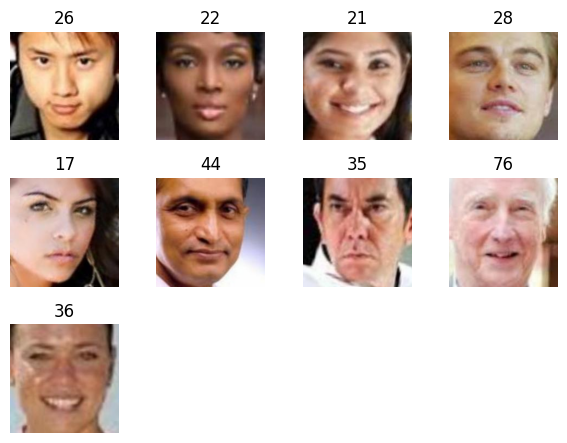

In [5]:
from PIL import Image

images = os.listdir(folder_path)

plt.figure(figsize=(6,6))

for i, img_name in enumerate(images[:9]):
    img_path = os.path.join(folder_path, img_name)
    img = Image.open(img_path)

    plt.subplot(4, 4, i+1)
    plt.imshow(img)
    plt.title(img_name.split('_')[0])
    plt.axis('off')

plt.tight_layout()
plt.show()

In [6]:
age = []
gender = []
img_path = []

for file in os.listdir(folder_path):
    try:
        age.append(int(file.split('_')[0]))
        gender.append(int(file.split('_')[1]))
        img_path.append(file)
    except:
        print("Skipped:", file)

Skipped: utkcropped


In [7]:
print(len(age), len(gender), len(img_path))

23709 23709 23709


In [8]:
df = pd.DataFrame({'age': age, 'gender': gender, 'img_path': img_path})

In [9]:
df.head()

,age,gender,img_path
0,26,0,26_0_2_20170104023102422.jpg.chip.jpg
1,22,1,22_1_1_20170112233644761.jpg.chip.jpg
2,21,1,21_1_3_20170105003215901.jpg.chip.jpg
3,28,0,28_0_0_20170117180555824.jpg.chip.jpg
4,17,1,17_1_4_20170103222931966.jpg.chip.jpg


In [10]:
df = df[df['gender']!=3]

In [11]:
df.shape

(23708, 3)

## Age Normalization

Normalize age to [0, 1] range to stabilize regression training.

Max age in UTKFace dataset is 116.

Note: flow_from_dataframe needs string columns, so we convert after normalization.

In [12]:
df['age'] = df['age'] / 116.0

# Convert to string so flow_from_dataframe can handle multi-output
df['age'] = df['age'].astype(str)
df['gender'] = df['gender'].astype(str)

In [13]:
df.head()

,age,gender,img_path
0,0.22413793103448276,0,26_0_2_20170104023102422.jpg.chip.jpg
1,0.1896551724137931,1,22_1_1_20170112233644761.jpg.chip.jpg
2,0.1810344827586207,1,21_1_3_20170105003215901.jpg.chip.jpg
3,0.2413793103448276,0,28_0_0_20170117180555824.jpg.chip.jpg
4,0.14655172413793102,1,17_1_4_20170103222931966.jpg.chip.jpg


## Train-Test Split

The dataset is divided into:
- 80% training data
- 20% testing data

A fixed random seed is used for reproducibility.

In [14]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=SEED,
    shuffle=True
)

print(train_df.shape)
print(test_df.shape)

(18966, 3)
(4742, 3)


In [15]:
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

## Data Generators

Using ImageDataGenerator instead of loading all images into memory.

This avoids memory crashes on large datasets like UTKFace.

In [16]:
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    horizontal_flip=True,
    rotation_range=5
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [17]:
train_generator = train_datagen.flow_from_dataframe(
    train_df,
    directory=folder_path,
    x_col='img_path',
    y_col=['age', 'gender'],
    target_size=(128, 128),
    batch_size=32,
    seed=SEED,
    class_mode='multi_output'
)

test_generator = test_datagen.flow_from_dataframe(
    test_df,
    directory=folder_path,
    x_col='img_path',
    y_col=['age', 'gender'],
    target_size=(128, 128),
    batch_size=32,
    seed=SEED,
    class_mode='multi_output'
)

Found 18966 validated image filenames.
Found 4742 validated image filenames.


## Generator Wrapper

flow_from_dataframe returns labels as a list.

The model expects a dict with output layer names, so we wrap the generator to fix that.

In [18]:
def multi_output_wrapper(generator):
    for x, y in generator:
        age_labels = y[0].astype('float32')
        gender_labels = y[1].astype('float32')
        yield x, {'age_out': age_labels, 'gender_out': gender_labels}

train_gen = multi_output_wrapper(train_generator)
test_gen = multi_output_wrapper(test_generator)

# VGG16 Transfer Learning Model

Strategy:
- Freeze base layers first, train only the head (Phase 1)
- Then unfreeze last 300 layers for fine-tuning (Phase 2)

In [ ]:
from tensorflow import keras
from keras.applications import VGG16
from keras.layers import *
from keras.models import Model

In [20]:
conv_base = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(128, 128, 3)
)

I0000 00:00:1780998425.078721      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780998425.084759      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [21]:
# Freeze all base layers first
conv_base.trainable = False

In [22]:
x = conv_base.output
x = GlobalAveragePooling2D()(x)

# Age branch
age_output = Dense(256, activation='relu')(x)
age_output = BatchNormalization()(age_output)
age_output = Dropout(0.2)(age_output)
age_output = Dense(1, activation='sigmoid', name='age_out')(age_output)  # sigmoid since age is normalized 0-1

# Gender branch
gender_output = Dense(256, activation='relu')(x)
gender_output = BatchNormalization()(gender_output)
gender_output = Dropout(0.2)(gender_output)
gender_output = Dense(1, activation='sigmoid', name='gender_out')(gender_output)

In [23]:
model = Model(
    inputs=conv_base.input,
    outputs=[age_output, gender_output]
)

In [24]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 128, 128,  │      1,792 │ input_layer[0][0] │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 128, 128,  │     36,928 │ block1_conv1[0][… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_pool         │ (None, 64, 64,    │          0 │ block1_conv2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv1        │ (None, 64, 64,    │     73,856 │ block1_pool[0][0] │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv2        │ (None, 64, 64,    │    147,584 │ block2_conv1[0][… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 32, 32,    │          0 │ block2_conv2[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv1        │ (None, 32, 32,    │    295,168 │ block2_pool[0][0] │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv2        │ (None, 32, 32,    │    590,080 │ block3_conv1[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv3        │ (None, 32, 32,    │    590,080 │ block3_conv2[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_pool         │ (None, 16, 16,    │          0 │ block3_conv3[0][… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv1        │ (None, 16, 16,    │  1,180,160 │ block3_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv2        │ (None, 16, 16,    │  2,359,808 │ block4_conv1[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv3        │ (None, 16, 16,    │  2,359,808 │ block4_conv2[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_pool         │ (None, 8, 8, 512) │          0 │ block4_conv3[0][… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv1        │ (None, 8, 8, 512) │  2,359,808 │ block4_pool[0][0] │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv2        │ (None, 8, 8, 512) │  2,359,808 │ block5_conv1[0][

 Total params: 14,979,906 (57.14 MB)

 Trainable params: 264,194 (1.01 MB)

 Non-trainable params: 14,715,712 (56.14 MB)

## Phase 1: Train only the head

Base is frozen. Only the dense layers get trained first.

This warms up the new layers before we fine-tune the base.

In [25]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import Huber

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss={
        'age_out': Huber(),
        'gender_out': 'binary_crossentropy'
    },
    metrics={
        'age_out': ['mae'],
        'gender_out': ['accuracy']
    }
)

In [26]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

checkpoint_phase1 = ModelCheckpoint(
    'VGG16_phase1.keras',
    monitor='val_loss',
    save_best_only=True,

    verbose=1
)

In [27]:
history_phase1 = model.fit(
    train_gen,
    steps_per_epoch=len(train_generator),
    validation_data=test_gen,
    validation_steps=len(test_generator),
    epochs=10,
    callbacks=[early_stopping, checkpoint_phase1]
)

Epoch 1/10


I0000 00:00:1780998462.844695     132 service.cc:152] XLA service 0x3bdb31f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780998462.844755     132 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1780998462.844762     132 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1780998463.676262     132 cuda_dnn.cc:529] Loaded cuDNN version 91002


  2/593 ━━━━━━━━━━━━━━━━━━━━ 44s 76ms/step - age_out_loss: 0.0701 - age_out_mae: 0.2914 - gender_out_accuracy: 0.7266 - gender_out_loss: 0.6495 - loss: 0.7196   

I0000 00:00:1780998471.756058     132 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


593/593 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step - age_out_loss: 0.0210 - age_out_mae: 0.1502 - gender_out_accuracy: 0.8110 - gender_out_loss: 0.4368 - loss: 0.4578
Epoch 1: val_loss improved from None to 0.36078, saving model to VGG16_phase1.keras

Epoch 1: finished saving model to VGG16_phase1.keras
593/593 ━━━━━━━━━━━━━━━━━━━━ 206s 329ms/step - age_out_loss: 0.0129 - age_out_mae: 0.1180 - gender_out_accuracy: 0.8274 - gender_out_loss: 0.3981 - loss: 0.4111 - val_age_out_loss: 0.0058 - val_age_out_mae: 0.0791 - val_gender_out_accuracy: 0.8439 - val_gender_out_loss: 0.3540 - val_loss: 0.3608
Epoch 2/10
593/593 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - age_out_loss: 0.0065 - age_out_mae: 0.0857 - gender_out_accuracy: 0.8536 - gender_out_loss: 0.3395 - loss: 0.3460
Epoch 2: val_loss improved from 0.36078 to 0.34489, saving model to VGG16_phase1.keras

Epoch 2: finished saving model to VGG16_phase1.keras
593/593 ━━━━━━━━━━━━━━━━━━━━ 112s 190ms/step - age_out_loss: 0.0061 - age_out_mae: 0.0834 - gen

## Phase 2: Fine-tuning

Unfreeze the last 30 layers of VGG16.

Use a much lower learning rate so we don't destroy pretrained weights.

In [81]:
conv_base.trainable = True

for layer in conv_base.layers[:-30]:
    layer.trainable = False

for layer in conv_base.layers[-30:]:
    layer.trainable = True

In [82]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

model.compile(
    optimizer=Adam(learning_rate=1e-4),   # lower lr for fine-tuning
    loss={
        'age_out': Huber(),
        'gender_out': 'binary_crossentropy'
    },
    metrics={
        'age_out': ['mae'],
        'gender_out': ['accuracy']
    }
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

checkpoint_phase2 = ModelCheckpoint(
    'VGG_final.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

early_stopping_2 = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

In [83]:
# Re-wrap generators since they were exhausted in phase 1
train_gen = multi_output_wrapper(train_generator)
test_gen = multi_output_wrapper(test_generator)

In [84]:
history_phase2 = model.fit(
    train_gen,
    steps_per_epoch=len(train_generator),
    validation_data=test_gen,
    validation_steps=len(test_generator),
    epochs=30,
    callbacks=[early_stopping_2, checkpoint_phase2, reduce_lr]
)

Epoch 1/30
593/593 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step - age_out_loss: 0.0080 - age_out_mae: 0.0939 - gender_out_accuracy: 0.8972 - gender_out_loss: 0.2552 - loss: 0.2632
Epoch 1: val_loss improved from None to 0.31269, saving model to VGG_final.keras

Epoch 1: finished saving model to VGG_final.keras
593/593 ━━━━━━━━━━━━━━━━━━━━ 152s 240ms/step - age_out_loss: 0.0058 - age_out_mae: 0.0823 - gender_out_accuracy: 0.9170 - gender_out_loss: 0.2048 - loss: 0.2107 - val_age_out_loss: 0.0053 - val_age_out_mae: 0.0805 - val_gender_out_accuracy: 0.8823 - val_gender_out_loss: 0.3104 - val_loss: 0.3127 - learning_rate: 1.0000e-04
Epoch 2/30
593/593 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step - age_out_loss: 0.0047 - age_out_mae: 0.0754 - gender_out_accuracy: 0.9331 - gender_out_loss: 0.1696 - loss: 0.1744
Epoch 2: val_loss did not improve from 0.31269
593/593 ━━━━━━━━━━━━━━━━━━━━ 135s 228ms/step - age_out_loss: 0.0047 - age_out_mae: 0.0748 - gender_out_accuracy: 0.9322 - gender_out_loss: 0.1719 - loss: 0.

## Training Results

Plots for Phase 2 (fine-tuning) training:
- Gender Accuracy
- Total Loss

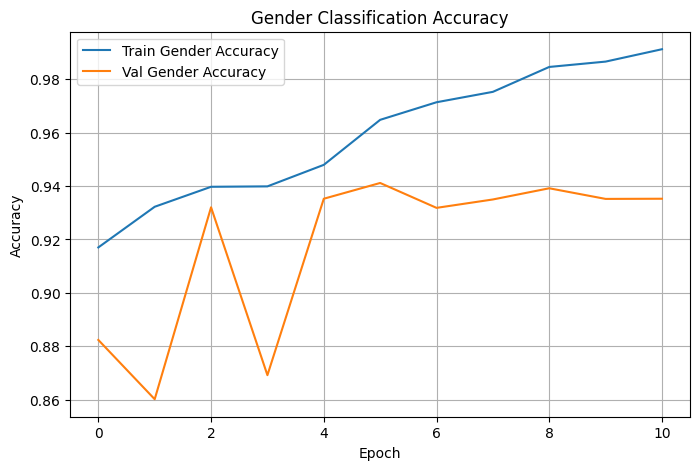

In [86]:
# Gender Accuracy
plt.figure(figsize=(8, 5))
plt.plot(history_phase2.history['gender_out_accuracy'], label='Train Gender Accuracy')
plt.plot(history_phase2.history['val_gender_out_accuracy'], label='Val Gender Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Gender Classification Accuracy')
plt.legend()
plt.grid(True)
plt.show()

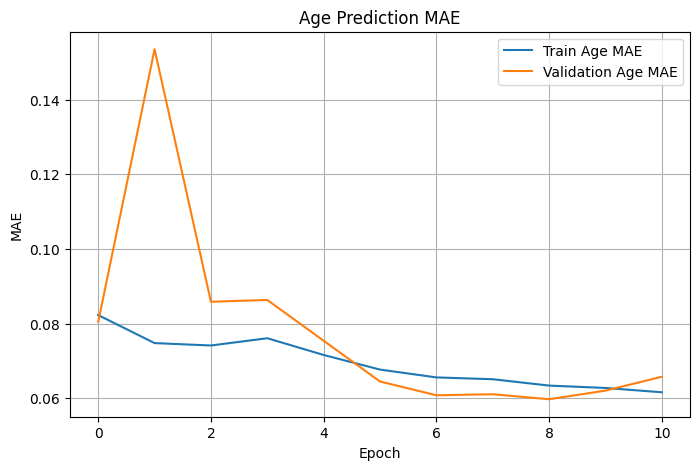

In [93]:
plt.figure(figsize=(8,5))

plt.plot(history_phase2.history['age_out_mae'],
         label='Train Age MAE')

plt.plot(history_phase2.history['val_age_out_mae'],
         label='Validation Age MAE')

plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.title('Age Prediction MAE')
plt.legend()
plt.grid(True)

plt.show()

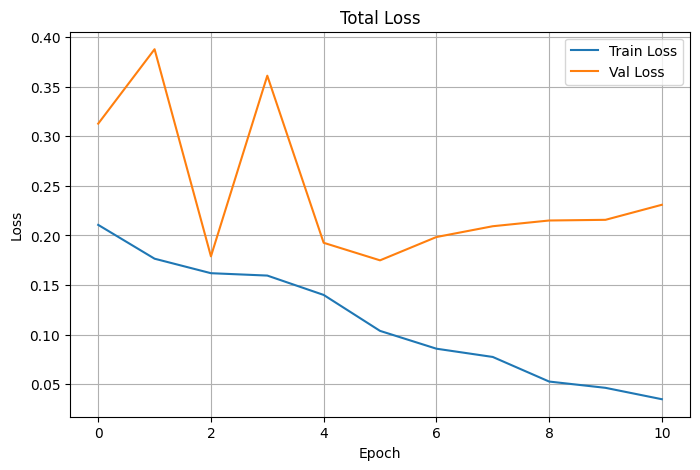

In [87]:
# Total Loss
plt.figure(figsize=(8, 5))
plt.plot(history_phase2.history['loss'], label='Train Loss')
plt.plot(history_phase2.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Total Loss')
plt.legend()
plt.grid(True)
plt.show()

## Model Evaluation

Load the best saved model and evaluate on test set.

Use a fresh generator with shuffle=False so predictions stay in order.

In [27]:
from tensorflow.keras.models import load_model

model = load_model('VGG_final.keras')

In [28]:
# Fresh generator with no shuffle for evaluation
eval_generator = test_datagen.flow_from_dataframe(
    test_df,
    directory=folder_path,
    x_col='img_path',
    target_size=(128, 128),
    batch_size=32,
    class_mode=None,
    shuffle=False
)

age_pred, gender_pred = model.predict(eval_generator)

Found 4742 validated image filenames.


I0000 00:00:1780936264.897395  882332 service.cc:153] XLA service 0x600007cb9c00 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780936264.897408  882332 service.cc:161]   StreamExecutor [0]: Host, Default Version (Driver: 0.0.0; Runtime: 0.0.0; Toolkit: 0.0.0; DNN: 0.0.0)
I0000 00:00:1780936264.901252  882332 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
W0000 00:00:1780936264.943543  907203 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.
I0000 00:00:1780936264.943585  907203 rsqrt.cc:179] Falling back to 1 / sqrt(x) for f32 false
I0000 00:00:1780936264.960394  882332 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


149/149 ━━━━━━━━━━━━━━━━━━━━ 96s 644ms/step


In [29]:
from sklearn.metrics import accuracy_score

y_test_gender = test_df['gender'].astype(float).values

gender_pred_binary = (gender_pred > 0.5).astype(int)

gender_acc = accuracy_score(
    y_test_gender,
    gender_pred_binary.flatten()
)

print("Gender Accuracy:", gender_acc)

Gender Accuracy: 0.9780683256010122


In [30]:
from sklearn.metrics import mean_absolute_error

y_test_age = test_df['age'].astype(float).values

# Denormalize age predictions back to actual years
age_pred_years = age_pred.flatten() * 116.0
y_test_age_years = y_test_age * 116.0

mae = mean_absolute_error(y_test_age_years, age_pred_years)


print("Age MAE (years):", mae)

Age MAE (years): 7.424767741092093
